<a href="https://colab.research.google.com/github/Surhan-Memon/concrete_slump_test_using_SVR/blob/main/concrete_slump_test_using_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/concrete_slump_test.csv')

In [3]:
df.head()

,No,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength(Mpa)
0,1,273,82,105,210,9,904,680,23.0,62.0,34.99
1,2,163,149,191,180,12,843,746,0.0,20.0,41.14
2,3,162,148,191,179,16,840,743,1.0,20.0,41.81
3,4,162,148,190,179,19,838,741,3.0,21.5,42.08
4,5,154,112,144,220,10,923,658,20.0,64.0,26.82


<Axes: >

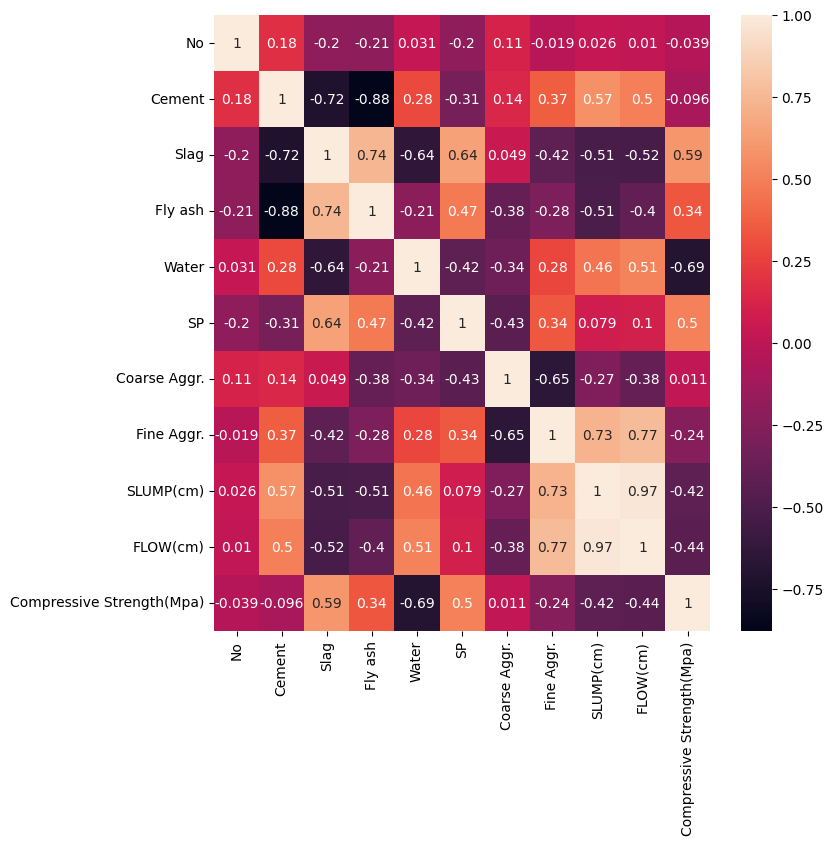

In [6]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)

In [7]:
df.columns

Index(['No', 'Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)', 'Compressive Strength(Mpa)'],
      dtype='object')

In [8]:
X = df.drop('Compressive Strength(Mpa)',axis=1)
y = df['Compressive Strength(Mpa)']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
scaled_X_train = scaler.fit_transform(X_train)

In [13]:
scaled_X_test = scaler.transform(X_test)

In [14]:
from sklearn.svm import SVR, LinearSVR

In [15]:
base_model = SVR()

In [16]:
base_model.fit(scaled_X_train,y_train)

SVR()

In [17]:
base_preds = base_model.predict(scaled_X_test)

In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
mean_absolute_error(y_test,base_preds)

3.560547714703764

In [20]:
np.sqrt(mean_squared_error(y_test,base_preds))

np.float64(5.122591765617332)

In [21]:
y_test.mean()

np.float64(30.856451612903225)

In [23]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1],
              'kernel':['linear','poly','rbf'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0,0.01,0.1,0.5,1,2]}

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
svr = SVR()

In [26]:
grid = GridSearchCV(svr,param_grid)

In [27]:
grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1], 'degree': [2, 3, 4],
                         'epsilon': [0, 0.01, 0.1, 0.5, 1, 2],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf']})

In [28]:
grid.best_estimator_

SVR(C=1, degree=2, epsilon=1, kernel='linear')

In [29]:
grid_preds = grid.predict(scaled_X_test)

In [30]:
mean_absolute_error(y_test,grid_preds)

1.8497948260729393

In [31]:
np.sqrt(mean_squared_error(y_test,grid_preds))

np.float64(2.3199763455380644)